In [1]:
# Titanic Dataset Exploratory Data Analysis
# Complete Assignment - All Tasks

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("="*60)
print("TITANIC DATASET EDA - COMPLETE ASSIGNMENT")
print("="*60)

TITANIC DATASET EDA - COMPLETE ASSIGNMENT


In [2]:
# TASK 1: Load the Titanic dataset
from google.colab import files

print("Step 1: Please upload your Titanic-Dataset (2).csv file")
uploaded = files.upload()

# Load the dataset
import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print(f"\n✅ Dataset loaded successfully!")
print(f"Dataset shape: {df.shape} rows × {df.shape[1]} columns")

Step 1: Please upload your Titanic-Dataset (2).csv file


Saving Titanic-Dataset (2).csv to Titanic-Dataset (2).csv

✅ Dataset loaded successfully!
Dataset shape: (891, 12) rows × 12 columns


In [3]:
# TASK 2: Inspect the data

print("\n" + "="*60)
print("TASK 2: DATA INSPECTION")
print("="*60)

# First 5 rows
print("\n📊 First 5 rows of the dataset:")
print(df.head())

# Last 5 rows
print("\n📊 Last 5 rows of the dataset:")
print(df.tail())

# Data types
print("\n📋 Data types of each column:")
print(df.dtypes)

# Summary statistics
print("\n📈 Summary statistics of numerical columns:")
print(df.describe())


TASK 2: DATA INSPECTION

📊 First 5 rows of the dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S 

In [11]:
# TASK 3: Clean and preprocess the data

print("\n" + "="*60)
print("TASK 3: DATA CLEANING & PREPROCESSING")
print("="*60)

# Create PclassCategory
df['PclassCategory'] = df['Pclass'].map({1: 'First Class', 2: 'Second Class', 3: 'Third Class'})
print("\n Created 'PclassCategory':")
print(df[['Pclass', 'PclassCategory']].head())

# Create CabinCategory (extract deck letter)
df['CabinCategory'] = df['Cabin'].fillna('Unknown').apply(lambda x: x[0] if x != 'Unknown' else 'Unknown')
print("\n Created 'CabinCategory' (Deck letter):")
print(df[['Cabin', 'CabinCategory']].head(10))

# Handle missing Age values
missing_age_before = df['Age'].isnull().sum()
mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)
print(f"\n Handled missing Age values:")
print(f"   - Missing before: {missing_age_before}")
print(f"   - Missing after: {df['Age'].isnull().sum()}")
print(f"   - Mean age used: {mean_age:.2f}")

# Create Family feature
df['Family'] = df['SibSp'] + df['Parch']
print(f"\n Created 'Family' feature (SibSp + Parch):")
print(df[['SibSp', 'Parch', 'Family']].head(10))
print(f"\n   Family size statistics:")
print(f"   - Min: {df['Family'].min()}")
print(f"   - Max: {df['Family'].max()}")
print(f"   - Mean: {df['Family'].mean():.2f}")


TASK 3: DATA CLEANING & PREPROCESSING

 Created 'PclassCategory':
   Pclass PclassCategory
0       3    Third Class
1       1    First Class
2       3    Third Class
3       1    First Class
4       3    Third Class

 Created 'CabinCategory' (Deck letter):
  Cabin CabinCategory
0   NaN       Unknown
1   C85             C
2   NaN       Unknown
3  C123             C
4   NaN       Unknown
5   NaN       Unknown
6   E46             E
7   NaN       Unknown
8   NaN       Unknown
9   NaN       Unknown

 Handled missing Age values:
   - Missing before: 0
   - Missing after: 0
   - Mean age used: 29.70

 Created 'Family' feature (SibSp + Parch):
   SibSp  Parch  Family
0      1      0       1
1      1      0       1
2      0      0       0
3      1      0       1
4      0      0       0
5      0      0       0
6      0      0       0
7      3      1       4
8      0      2       2
9      1      0       1

   Family size statistics:
   - Min: 0
   - Max: 10
   - Mean: 0.90


In [10]:
# TASK 4: Identify specific data points

print("\n" + "="*60)
print("TASK 4: SPECIFIC DATA POINTS")
print("="*60)

# Highest fare passengers
highest_fare = df['Fare'].max()
highest_fare_passengers = df[df['Fare'] == highest_fare][['Name', 'Fare', 'Pclass', 'Sex', 'Age']]
print(f"\n Highest fare paid: ${highest_fare:.2f}")
print("Passenger(s) with the highest fare:")
print(highest_fare_passengers.to_string(index=False))

# Largest family size
largest_family = df['Family'].max()
largest_family_passengers = df[df['Family'] == largest_family][['Name', 'SibSp', 'Parch', 'Family', 'Survived']]
print(f"\n Largest family size: {largest_family}")
print("Passenger(s) with the largest family size:")
print(largest_family_passengers.to_string(index=False))


TASK 4: SPECIFIC DATA POINTS

 Highest fare paid: $512.33
Passenger(s) with the highest fare:
                              Name     Fare  Pclass    Sex  Age
                  Ward, Miss. Anna 512.3292       1 female 35.0
Cardeza, Mr. Thomas Drake Martinez 512.3292       1   male 36.0
            Lesurer, Mr. Gustave J 512.3292       1   male 35.0

 Largest family size: 10
Passenger(s) with the largest family size:
                             Name  SibSp  Parch  Family  Survived
       Sage, Master. Thomas Henry      8      2      10         0
     Sage, Miss. Constance Gladys      8      2      10         0
              Sage, Mr. Frederick      8      2      10         0
         Sage, Mr. George John Jr      8      2      10         0
          Sage, Miss. Stella Anna      8      2      10         0
         Sage, Mr. Douglas Bullen      8      2      10         0
Sage, Miss. Dorothy Edith "Dolly"      8      2      10         0


In [9]:
# TASK 5: Demonstrate Pandas Series and DataFrame functionalities

print("\n" + "="*60)
print("TASK 5: SERIES & DATAFRAME FUNCTIONALITIES")
print("="*60)

# Create a Series of passenger names
names_series = pd.Series(df['Name'].values, name='Passenger Names')
print("\n Series of passenger names (first 10):")
print(names_series.head(10))
print(f"Series type: {type(names_series)}")

# Create a DataFrame of passenger names and ages
names_ages_df = df[['Name', 'Age']].copy()
print("\n DataFrame of passenger names and ages (first 10):")
print(names_ages_df.head(10))
print(f"DataFrame type: {type(names_ages_df)}")

# Slice to show only passengers older than 50
older_passengers = df[df['Age'] > 50][['Name', 'Age', 'Sex', 'Pclass', 'Survived']]
print(f"\n Passengers older than 50: {len(older_passengers)}")
print("First 10:")
print(older_passengers.head(10).to_string(index=False))


TASK 5: SERIES & DATAFRAME FUNCTIONALITIES

 Series of passenger names (first 10):
0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Passenger Names, dtype: object
Series type: <class 'pandas.core.series.Series'>

 DataFrame of passenger names and ages (first 10):
                                                Name        Age
0                            Braund, Mr. Owen Harris  22.000000
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.000000
2                             Heikki

In [8]:
# TASK 6: Multi-indexing

print("\n" + "="*60)
print("TASK 6: MULTI-INDEXING")
print("="*60)

# Create multi-index DataFrame grouped by Sex and Pclass
multi_index_df = df.groupby(['Sex', 'Pclass']).agg(
    Survival_Rate=('Survived', 'mean'),
    Count=('Survived', 'count'),
    Total=('Survived', 'sum')
).round(4)

multi_index_df['Survival_Percentage'] = multi_index_df['Survival_Rate'] * 100

print("\n Multi-index DataFrame - Survival rates by Sex and Passenger Class:")
print(multi_index_df)
print(f"\nMulti-index levels: {multi_index_df.index.names}")


TASK 6: MULTI-INDEXING

 Multi-index DataFrame - Survival rates by Sex and Passenger Class:
               Survival_Rate  Count  Total  Survival_Percentage
Sex    Pclass                                                  
female 1              0.9681     94     91                96.81
       2              0.9211     76     70                92.11
       3              0.5000    144     72                50.00
male   1              0.3689    122     45                36.89
       2              0.1574    108     17                15.74
       3              0.1354    347     47                13.54

Multi-index levels: ['Sex', 'Pclass']



TASK 7: VISUALIZATIONS


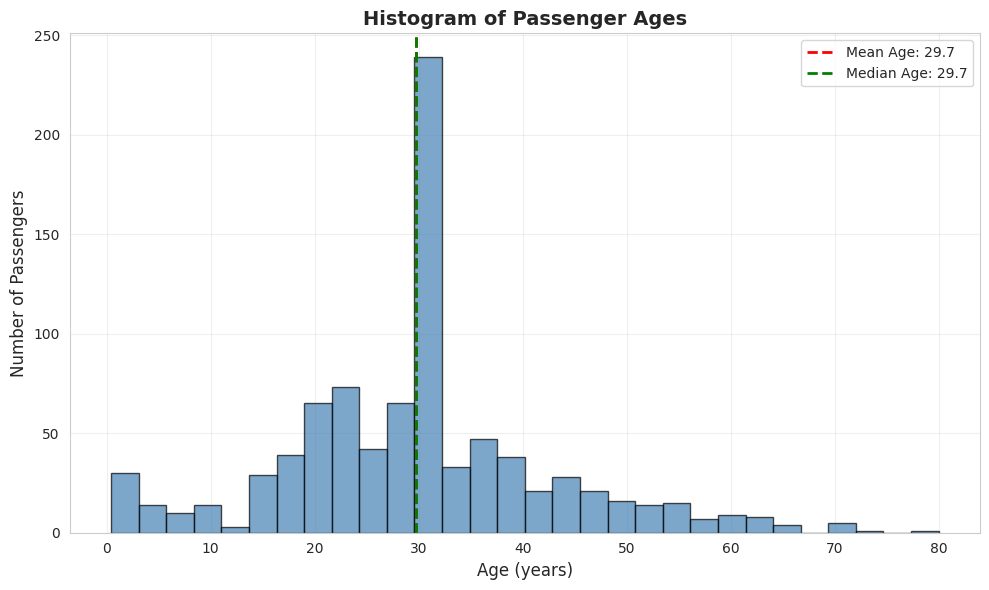

 Histogram saved as 'age_histogram.png'


In [12]:
# TASK 7: Visualizations (Part 1 - Histogram)

print("\n" + "="*60)
print("TASK 7: VISUALIZATIONS")
print("="*60)

# Histogram of passenger ages
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Passenger Ages', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.axvline(df['Age'].mean(), color='red', linestyle='dashed', linewidth=2,
            label=f'Mean Age: {df["Age"].mean():.1f}')
plt.axvline(df['Age'].median(), color='green', linestyle='dashed', linewidth=2,
            label=f'Median Age: {df["Age"].median():.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('age_histogram.png', dpi=150)
plt.show()
print(" Histogram saved as 'age_histogram.png'")

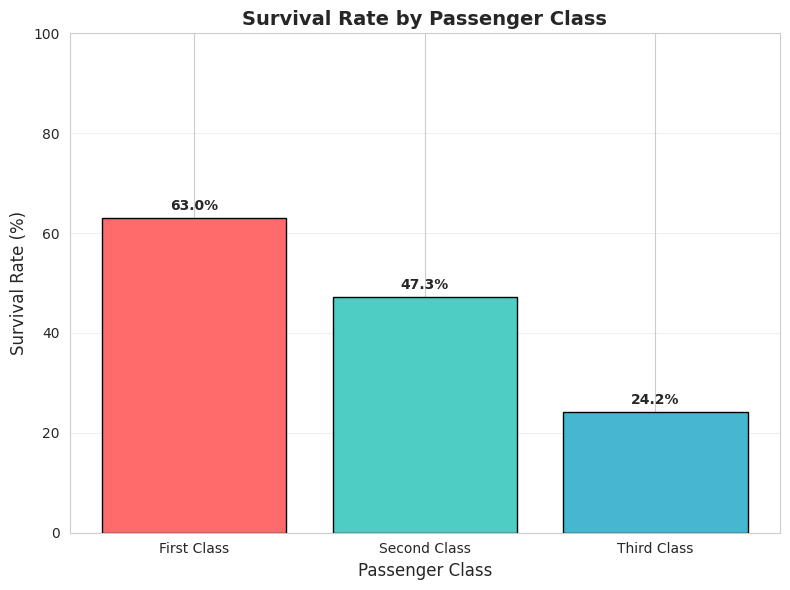

 Bar plot saved as 'survival_by_class.png'


In [13]:
# TASK 7: Visualizations (Part 2 - Bar plot of survival rates)

# Bar plot of survival rates by passenger class
survival_by_class = df.groupby('PclassCategory')['Survived'].mean() * 100

plt.figure(figsize=(8, 6))
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
bars = plt.bar(survival_by_class.index, survival_by_class.values, color=colors, edgecolor='black')
plt.title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)

for bar, value in zip(bars, survival_by_class.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 100)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('survival_by_class.png', dpi=150)
plt.show()
print(" Bar plot saved as 'survival_by_class.png'")

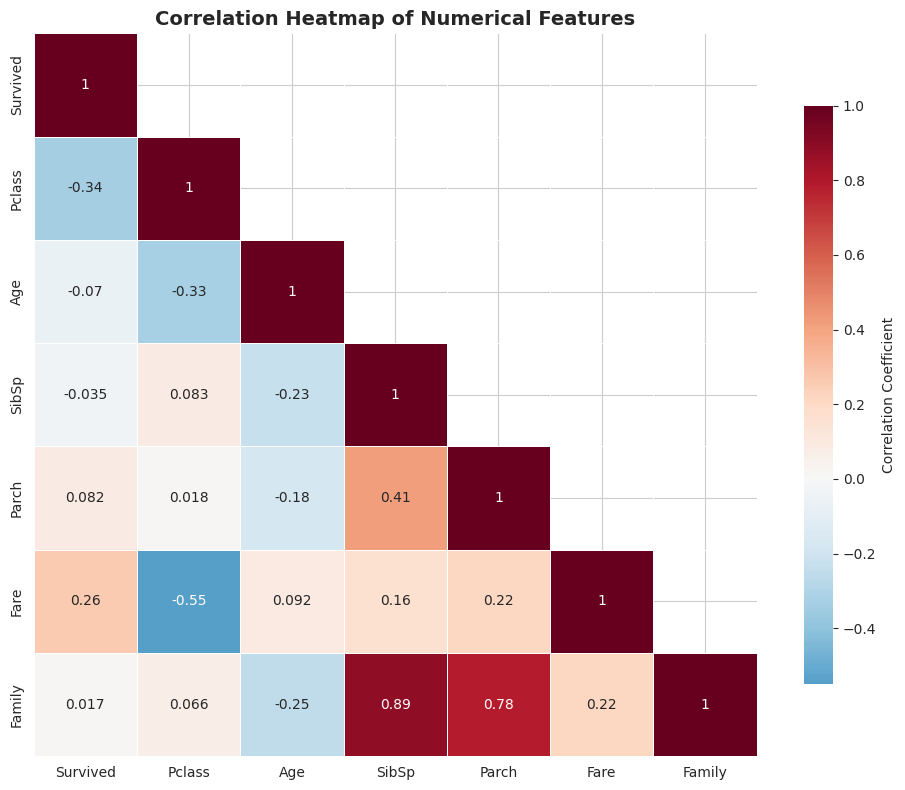

 Heatmap saved as 'correlation_heatmap.png'


In [14]:
# TASK 7: Visualizations (Part 3 - Heatmap)

# Heatmap of correlations
numerical_features = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Family']
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print(" Heatmap saved as 'correlation_heatmap.png'")

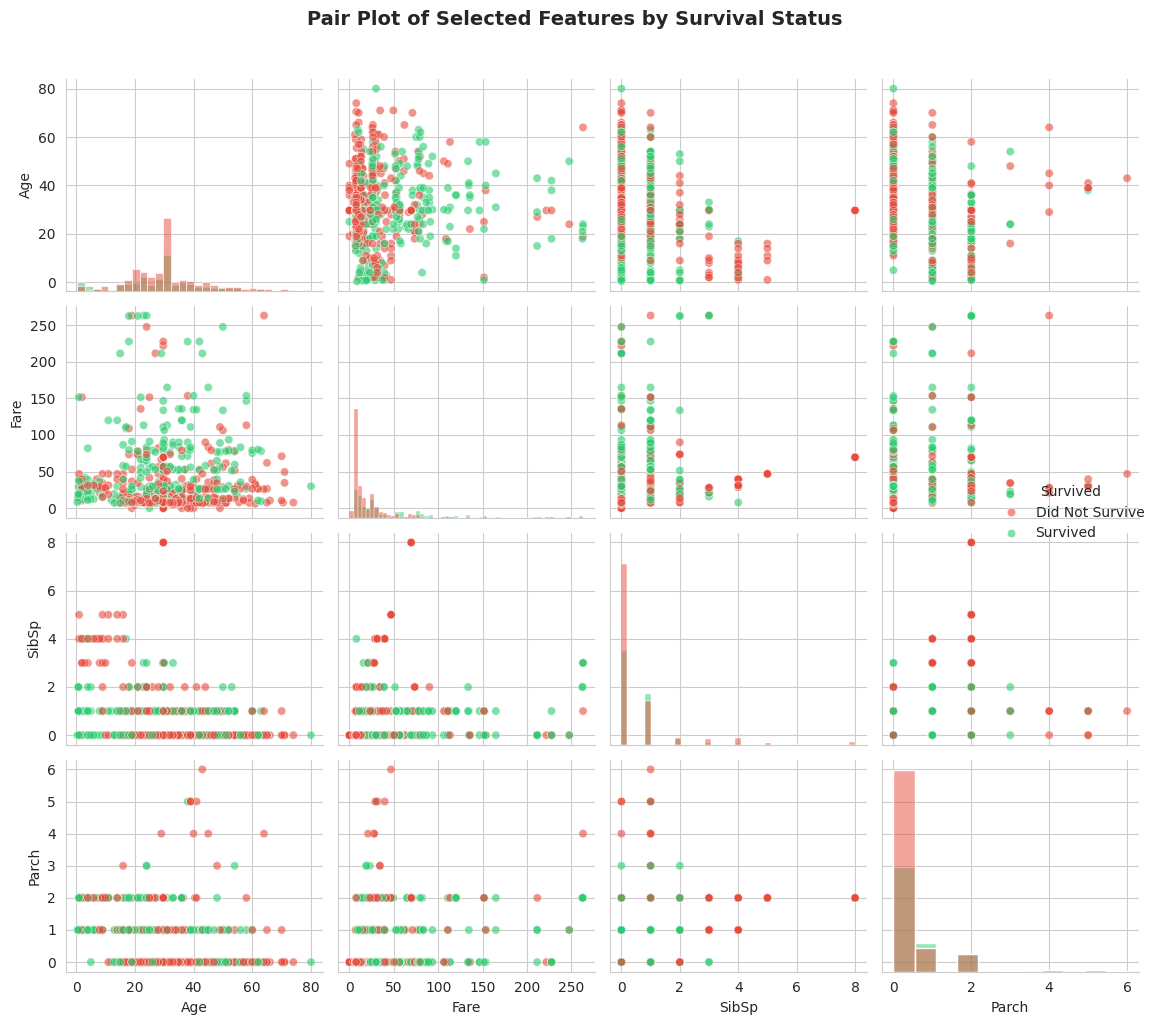

 Pair plot saved as 'pair_plot.png'


In [15]:
# TASK 7: Visualizations (Part 4 - Pair plot)

# Pair plot of selected features
sample_df = df[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']].copy()
sample_df['Survived'] = sample_df['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})
sample_df = sample_df[sample_df['Fare'] < 300]

pair_plot = sns.pairplot(sample_df, hue='Survived',
                          vars=['Age', 'Fare', 'SibSp', 'Parch'],
                          palette={'Survived': '#2ecc71', 'Did Not Survive': '#e74c3c'},
                          diag_kind='hist', plot_kws={'alpha': 0.6})
pair_plot.fig.suptitle('Pair Plot of Selected Features by Survival Status',
                        y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pair_plot.png', dpi=150)
plt.show()
print(" Pair plot saved as 'pair_plot.png'")


TASK 8: SURVIVAL RATES ANALYSIS

 Survival Rates by Sex:
          mean  count  Survival_Rate_Pct
Sex                                     
female  0.7420    314              74.20
male    0.1889    577              18.89


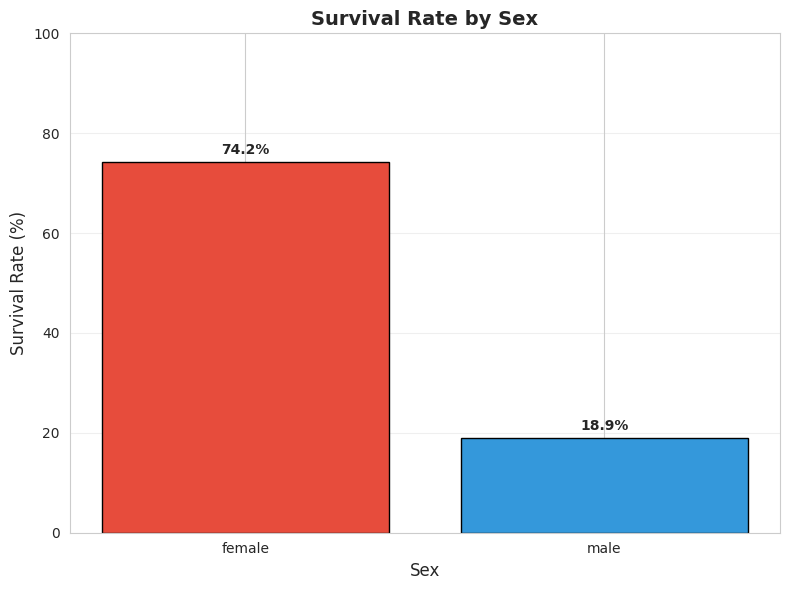


 Survival Rates by Passenger Class:
                  mean  count  Survival_Rate_Pct
PclassCategory                                  
First Class     0.6296    216              62.96
Second Class    0.4728    184              47.28
Third Class     0.2424    491              24.24


In [16]:
# TASK 8: Analyze survival rates

print("\n" + "="*60)
print("TASK 8: SURVIVAL RATES ANALYSIS")
print("="*60)

# Survival rates by sex
survival_by_sex = df.groupby('Sex')['Survived'].agg(['mean', 'count']).round(4)
survival_by_sex['Survival_Rate_Pct'] = survival_by_sex['mean'] * 100

print("\n Survival Rates by Sex:")
print(survival_by_sex)

# Visualization
plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#3498db']
bars = plt.bar(survival_by_sex.index, survival_by_sex['Survival_Rate_Pct'],
               color=colors, edgecolor='black')
plt.title('Survival Rate by Sex', fontsize=14, fontweight='bold')
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)

for bar, value in zip(bars, survival_by_sex['Survival_Rate_Pct']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 100)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('survival_by_sex.png', dpi=150)
plt.show()

# Survival rates by passenger class
survival_by_class_detail = df.groupby('PclassCategory')['Survived'].agg(['mean', 'count']).round(4)
survival_by_class_detail['Survival_Rate_Pct'] = survival_by_class_detail['mean'] * 100

print("\n Survival Rates by Passenger Class:")
print(survival_by_class_detail)


TASK 9: AGE DISTRIBUTION ANALYSIS


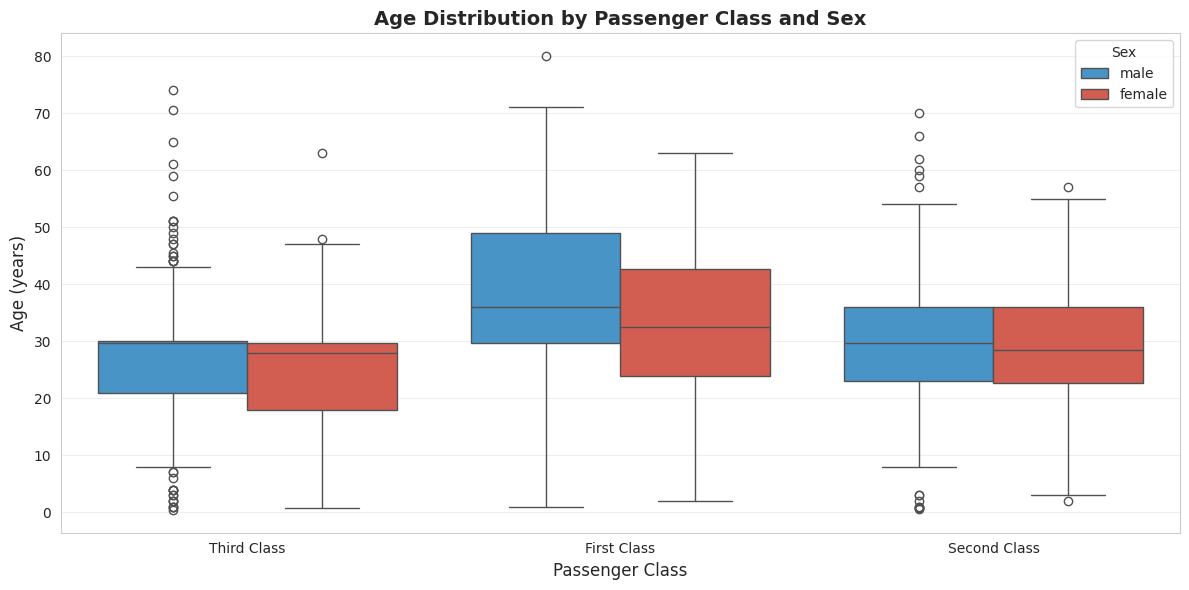

 Box plot saved as 'age_distribution_boxplot.png'

 Age Distribution Insights:
- First class passengers tend to be older
- Third class has more children and young adults
- Female passengers show wider age distribution across classes


In [17]:
# TASK 9: Analyze age distribution (Box plot)

print("\n" + "="*60)
print("TASK 9: AGE DISTRIBUTION ANALYSIS")
print("="*60)

plt.figure(figsize=(12, 6))
sns.boxplot(x='PclassCategory', y='Age', hue='Sex', data=df,
            palette={'male': '#3498db', 'female': '#e74c3c'})
plt.title('Age Distribution by Passenger Class and Sex', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Age (years)', fontsize=12)
plt.legend(title='Sex', title_fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('age_distribution_boxplot.png', dpi=150)
plt.show()
print(" Box plot saved as 'age_distribution_boxplot.png'")

print("\n Age Distribution Insights:")
print("- First class passengers tend to be older")
print("- Third class has more children and young adults")
print("- Female passengers show wider age distribution across classes")


TASK 10: FARE DISTRIBUTION ANALYSIS


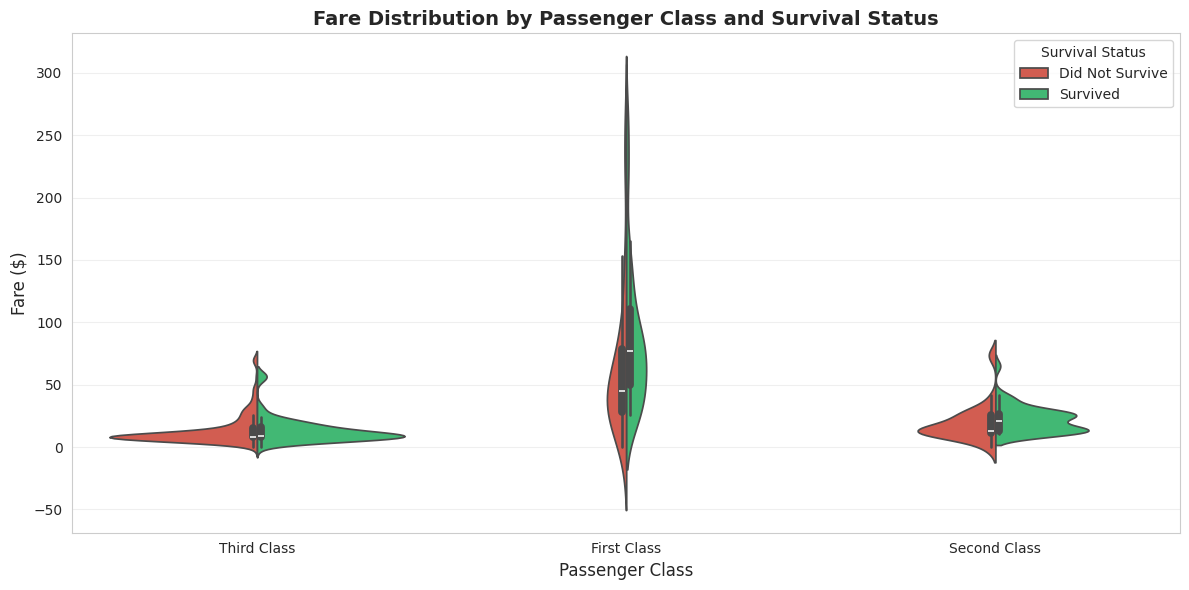

 Violin plot saved as 'fare_distribution_violin.png'

 Fare Distribution Insights:
- Higher fares correlate with higher survival rates
- First class survivors paid significantly higher fares
- Third class fare distribution is concentrated at lower values


In [18]:
# TASK 10: Analyze fare distribution (Violin plot)

print("\n" + "="*60)
print("TASK 10: FARE DISTRIBUTION ANALYSIS")
print("="*60)

plt.figure(figsize=(12, 6))

fare_filtered = df[df['Fare'] < 300].copy()
fare_filtered['Survival_Status'] = fare_filtered['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})

sns.violinplot(x='PclassCategory', y='Fare', hue='Survival_Status',
               data=fare_filtered, split=True,
               palette={'Survived': '#2ecc71', 'Did Not Survive': '#e74c3c'})
plt.title('Fare Distribution by Passenger Class and Survival Status', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Fare ($)', fontsize=12)
plt.legend(title='Survival Status', title_fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fare_distribution_violin.png', dpi=150)
plt.show()
print(" Violin plot saved as 'fare_distribution_violin.png'")

print("\n Fare Distribution Insights:")
print("- Higher fares correlate with higher survival rates")
print("- First class survivors paid significantly higher fares")
print("- Third class fare distribution is concentrated at lower values")

In [19]:
# FINAL SUMMARY

print("\n" + "="*60)
print("EDA COMPLETED SUCCESSFULLY!")
print("="*60)

print("\n Files generated:")
print("   - age_histogram.png")
print("   - survival_by_class.png")
print("   - correlation_heatmap.png")
print("   - pair_plot.png")
print("   - survival_by_sex.png")
print("   - age_distribution_boxplot.png")
print("   - fare_distribution_violin.png")

print("\n Key Insights Summary:")
print("   1. Female survival rate (~74%) much higher than male (~19%)")
print("   2. First class survival rate (~63%) > Second class (~47%) > Third class (~24%)")
print("   3. Higher fares correlate with better survival chances")
print("   4. Age distribution varies significantly by passenger class")
print("   5. Strong negative correlation between Pclass and Fare")

print("\n All 10 tasks completed!")


EDA COMPLETED SUCCESSFULLY!

 Files generated:
   - age_histogram.png
   - survival_by_class.png
   - correlation_heatmap.png
   - pair_plot.png
   - survival_by_sex.png
   - age_distribution_boxplot.png
   - fare_distribution_violin.png

 Key Insights Summary:
   1. Female survival rate (~74%) much higher than male (~19%)
   2. First class survival rate (~63%) > Second class (~47%) > Third class (~24%)
   3. Higher fares correlate with better survival chances
   4. Age distribution varies significantly by passenger class
   5. Strong negative correlation between Pclass and Fare

 All 10 tasks completed!
